Beginner level tasks

1. Multiprocessing
    * get to know yfinance (pandas_datareader) python library to download stock prices for given dates
    * download/save stock prices of sp500 for 1y/5y using single process vs multiprocessing
    * compare and visualize results

In [ ]:
# !pip install yfinance
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
import multiprocessing
from multiprocessing import Pool
from datetime import datetime, timedelta

In [2]:
# Top 10 S&P 500 tickers
TICKERS = ["AAPL", "MSFT", "NVDA", "AMZN", "META",
           "GOOGL", "TSLA", "JPM", "V", "JNJ"]

# Date Ranges
END_DATE  = datetime.today().strftime("%Y-%m-%d")
START_1Y  = (datetime.today() - timedelta(days=365)).strftime("%Y-%m-%d")
START_5Y  = (datetime.today() - timedelta(days=365 * 5)).strftime("%Y-%m-%d")

N_WORKERS = min(multiprocessing.cpu_count(), len(TICKERS))

print(f"Tickers  : {TICKERS}")
print(f"1Y range : {START_1Y} - {END_DATE}")
print(f"5Y range : {START_5Y} - {END_DATE}")
print(f"Workers  : {N_WORKERS}")

Tickers  : ['AAPL', 'MSFT', 'NVDA', 'AMZN', 'META', 'GOOGL', 'TSLA', 'JPM', 'V', 'JNJ']
1Y range : 2025-03-04 - 2026-03-04
5Y range : 2021-03-05 - 2026-03-04
Workers  : 2


In [3]:
def download_single_ticker(ticker: str, start: str, end: str) -> pd.DataFrame:
    """Download closing price for one ticker."""
    try:
        df = yf.download(ticker, start=start, end=end,
                         progress=False, auto_adjust=True)
        if df.empty:
            return pd.DataFrame()

        close = df[["Close"]].copy()
        close.columns = [ticker]
        return close

    except Exception as e:
        print(f"{ticker}: {e}")
        return pd.DataFrame()


def multiprocessing_worker(args):
    """
      Picklable worker for multiprocessing.Pool.
    """
    ticker, start, end = args
    return download_single_ticker(ticker, start, end)

In [4]:
def run_single_process(tickers, start, end, label=""):
    """Download all tickers sequentially"""
    print(f"SINGLE PROCESS | {label}")

    t0 = time.time()
    frames = []

    for i, ticker in enumerate(tickers, 1):
        df = download_single_ticker(ticker, start, end)

        if not df.empty:
            frames.append(df)

    elapsed  = time.time() - t0
    combined = pd.concat(frames, axis=1) if frames else pd.DataFrame()

    print(f"Done in {elapsed:.2f}s, {combined.shape[1]} tickers \n")
    return combined, elapsed

In [5]:
# 1 Year
data_1y_sp, time_1y_sp = run_single_process(TICKERS, START_1Y, END_DATE, "1 Year")

# 5 Years
data_5y_sp, time_5y_sp = run_single_process(TICKERS, START_5Y, END_DATE, "5 Years")


SINGLE PROCESS | 1 Year
Done in 2.62s, 10 tickers 

SINGLE PROCESS | 5 Years
Done in 3.46s, 10 tickers 



In [6]:
def run_multiprocessing(tickers, start, end, n_workers=None, label=""):
    """ Download all tickers in parallel """
    if n_workers is None:
        n_workers = min(multiprocessing.cpu_count(), len(tickers))

    print(f"MULTIPROCESSING ({n_workers} workers) | {label}")

    args = [(t, start, end) for t in tickers]

    t0 = time.time()
    with Pool(processes=n_workers) as pool:
        results = pool.map(multiprocessing_worker, args)

    elapsed = time.time() - t0

    frames   = [r for r in results if not r.empty]
    combined = pd.concat(frames, axis=1) if frames else pd.DataFrame()

    print(f"Done in {elapsed:.2f}s, {combined.shape[1]} tickers \n")
    return combined, elapsed

In [7]:
# 1 Year
data_1y_mp, time_1y_mp = run_multiprocessing(
    TICKERS, START_1Y, END_DATE, N_WORKERS, "1 Year"
)

# 5 Years
data_5y_mp, time_5y_mp = run_multiprocessing(
    TICKERS, START_5Y, END_DATE, N_WORKERS, "5 Years"
)

MULTIPROCESSING (2 workers) | 1 Year
Done in 0.48s, 10 tickers 

MULTIPROCESSING (2 workers) | 5 Years
Done in 0.93s, 10 tickers 



In [8]:
results = {
    "Period"    : ["1 Year", "5 Years"],
    "Single (s)": [round(time_1y_sp, 2), round(time_5y_sp, 2)],
    "Multi (s)" : [round(time_1y_mp, 2), round(time_5y_mp, 2)],
    "Speedup"   : [
        round(time_1y_sp / time_1y_mp, 2),
        round(time_5y_sp / time_5y_mp, 2),
    ],
    "Workers"   : [N_WORKERS, N_WORKERS],
}

df_results = pd.DataFrame(results).set_index("Period")
print("\n Performance Comparison")
print(df_results.to_string())
print(f"\n Avg speedup: {df_results['Speedup'].mean():.2f}×")


 Performance Comparison
         Single (s)  Multi (s)  Speedup  Workers
Period                                          
1 Year         2.62       0.48     5.42        2
5 Years        3.46       0.93     3.70        2

 Avg speedup: 4.56×


In [9]:
COLORS = {
    "single" : "#E74C3C",
    "multi"  : "#2ECC71",
    "accent" : "#3498DB",
    "bg"     : "#0F1117",
    "panel"  : "#1A1D27",
    "text"   : "#ECF0F1",
    "subtext": "#95A5A6",
    "grid"   : "#2C3E50",
}

def apply_dark_style(ax, title="", xlabel="", ylabel=""):
    ax.set_facecolor(COLORS["panel"])
    ax.tick_params(colors=COLORS["subtext"], labelsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor(COLORS["grid"])
    ax.xaxis.label.set_color(COLORS["subtext"])
    ax.yaxis.label.set_color(COLORS["subtext"])
    ax.title.set_color(COLORS["text"])
    ax.grid(color=COLORS["grid"], linestyle="--", linewidth=0.5, alpha=0.7)
    if title:  ax.set_title(title, fontsize=11, fontweight="bold", pad=10)
    if xlabel: ax.set_xlabel(xlabel, fontsize=9)
    if ylabel: ax.set_ylabel(ylabel, fontsize=9)

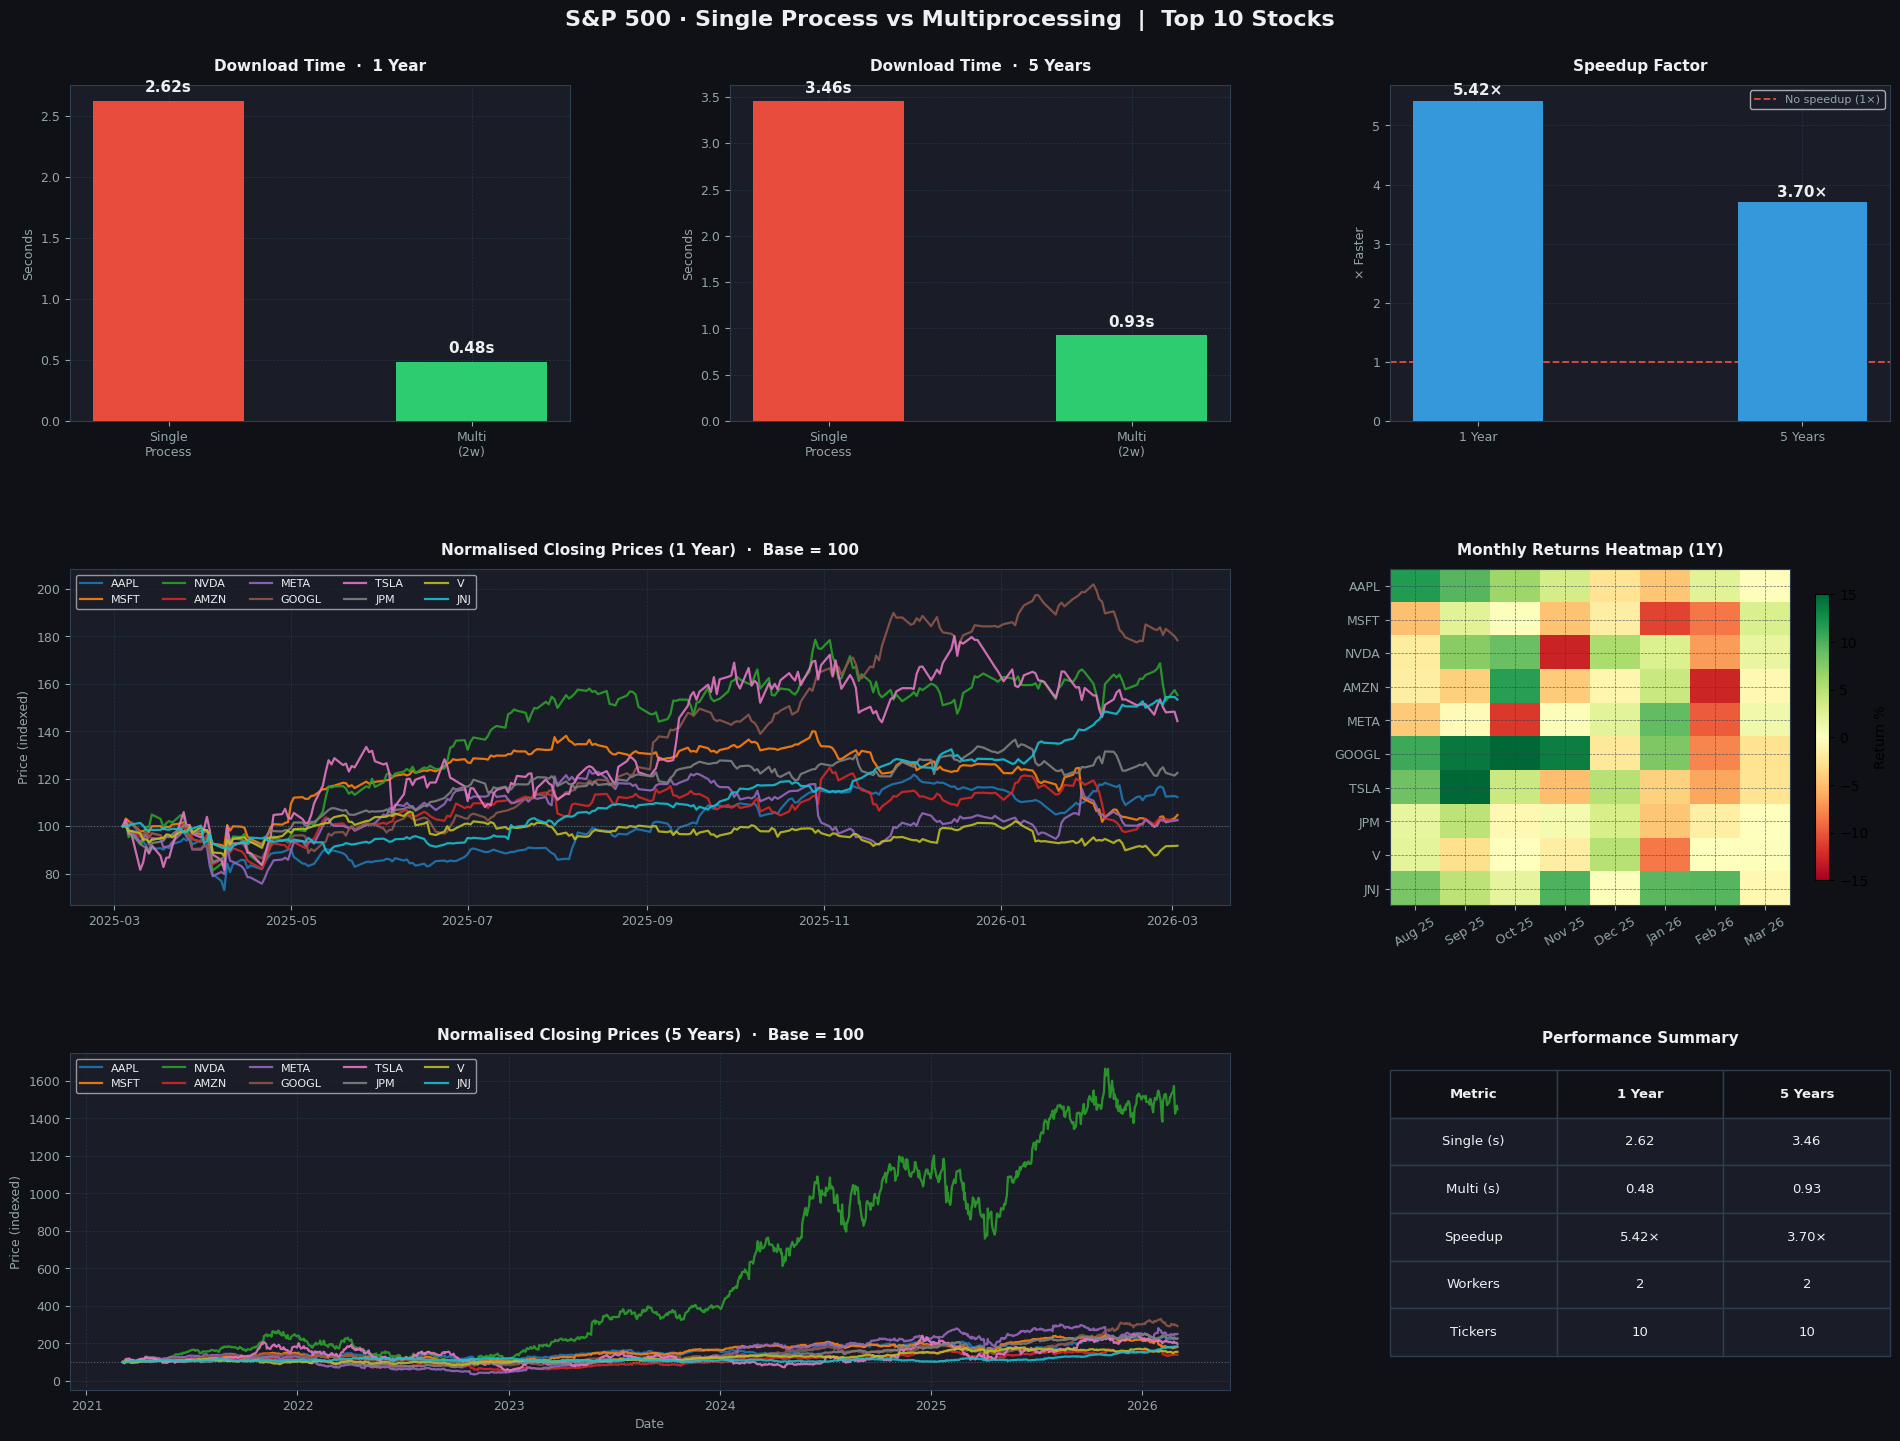

In [10]:
fig = plt.figure(figsize=(20, 15), facecolor=COLORS["bg"])
fig.suptitle(
    "S&P 500 · Single Process vs Multiprocessing  |  Top 10 Stocks",
    fontsize=16, fontweight="bold", color=COLORS["text"], y=0.98
)

gs = gridspec.GridSpec(3, 3, figure=fig,
                       hspace=0.44, wspace=0.32,
                       top=0.93, bottom=0.06, left=0.06, right=0.97)

palette = plt.cm.tab10(np.linspace(0, 1, len(TICKERS)))

# ── Row 0: Download time bars ─────────────────────────────────────────────────
for col, (sp_t, mp_t, period) in enumerate([
    (time_1y_sp, time_1y_mp, "1 Year"),
    (time_5y_sp, time_5y_mp, "5 Years"),
]):
    ax = fig.add_subplot(gs[0, col])
    bars = ax.bar(
        ["Single\nProcess", f"Multi\n({N_WORKERS}w)"],
        [sp_t, mp_t],
        color=[COLORS["single"], COLORS["multi"]],
        width=0.5, zorder=3
    )
    for bar, val in zip(bars, [sp_t, mp_t]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.05,
                f"{val:.2f}s", ha="center", va="bottom",
                color=COLORS["text"], fontsize=11, fontweight="bold")
    apply_dark_style(ax, f"Download Time  ·  {period}", ylabel="Seconds")

# ── Row 0: Speedup bar ───────────────────────────────────────────────────────
ax_spd = fig.add_subplot(gs[0, 2])
spd1 = time_1y_sp / time_1y_mp
spd5 = time_5y_sp / time_5y_mp
ax_spd.bar(["1 Year", "5 Years"], [spd1, spd5],
           color=COLORS["accent"], width=0.4, zorder=3)
ax_spd.axhline(1, color=COLORS["single"], linestyle="--",
               linewidth=1.3, label="No speedup (1×)")
for x, val in enumerate([spd1, spd5]):
    ax_spd.text(x, val + 0.05, f"{val:.2f}×",
                ha="center", va="bottom",
                color=COLORS["text"], fontsize=11, fontweight="bold")
ax_spd.legend(fontsize=8, facecolor=COLORS["panel"], labelcolor=COLORS["subtext"])
apply_dark_style(ax_spd, "Speedup Factor", ylabel="× Faster")

# ── Row 1: Normalised prices 1Y ───────────────────────────────────────────────
ax_l1 = fig.add_subplot(gs[1, :2])
for ticker, color in zip(TICKERS, palette):
    if ticker in data_1y_mp.columns:
        s = data_1y_mp[ticker].dropna()
        ax_l1.plot(s.index, s / s.iloc[0] * 100,
                   label=ticker, color=color, linewidth=1.6, alpha=0.9)
ax_l1.axhline(100, color=COLORS["subtext"], linestyle=":", linewidth=0.8, alpha=0.5)
ax_l1.legend(ncol=5, fontsize=8, facecolor=COLORS["panel"],
             labelcolor=COLORS["text"], loc="upper left", framealpha=0.7)
apply_dark_style(ax_l1, "Normalised Closing Prices (1 Year)  ·  Base = 100",
                 ylabel="Price (indexed)")

# ── Row 1: Heatmap 1Y monthly returns ────────────────────────────────────────
ax_h = fig.add_subplot(gs[1, 2])
ret  = data_1y_mp.pct_change().dropna()
mo   = ret.resample("ME").sum() * 100
mo   = mo.tail(8)
mo.index = mo.index.strftime("%b %y")
im = ax_h.imshow(mo.T.values, aspect="auto", cmap="RdYlGn", vmin=-15, vmax=15)
ax_h.set_xticks(range(len(mo.index)))
ax_h.set_xticklabels(mo.index, color=COLORS["subtext"], fontsize=7.5, rotation=30)
ax_h.set_yticks(range(len(TICKERS)))
ax_h.set_yticklabels(TICKERS, color=COLORS["subtext"], fontsize=8)
plt.colorbar(im, ax=ax_h, label="Return %", shrink=0.85)
apply_dark_style(ax_h, "Monthly Returns Heatmap (1Y)")

# ── Row 2: Normalised prices 5Y ───────────────────────────────────────────────
ax_l5 = fig.add_subplot(gs[2, :2])
for ticker, color in zip(TICKERS, palette):
    if ticker in data_5y_mp.columns:
        s = data_5y_mp[ticker].dropna()
        ax_l5.plot(s.index, s / s.iloc[0] * 100,
                   label=ticker, color=color, linewidth=1.6, alpha=0.9)
ax_l5.axhline(100, color=COLORS["subtext"], linestyle=":", linewidth=0.8, alpha=0.5)
ax_l5.legend(ncol=5, fontsize=8, facecolor=COLORS["panel"],
             labelcolor=COLORS["text"], loc="upper left", framealpha=0.7)
apply_dark_style(ax_l5, "Normalised Closing Prices (5 Years)  ·  Base = 100",
                 xlabel="Date", ylabel="Price (indexed)")

# ── Row 2: Summary stats table ────────────────────────────────────────────────
ax_t = fig.add_subplot(gs[2, 2])
ax_t.axis("off")
rows = [
    ["Metric",       "1 Year",             "5 Years"],
    ["Single (s)",   f"{time_1y_sp:.2f}",  f"{time_5y_sp:.2f}"],
    ["Multi (s)",    f"{time_1y_mp:.2f}",  f"{time_5y_mp:.2f}"],
    ["Speedup",      f"{spd1:.2f}×",       f"{spd5:.2f}×"],
    ["Workers",      str(N_WORKERS),       str(N_WORKERS)],
    ["Tickers",      str(len(TICKERS)),    str(len(TICKERS))],
]
tbl = ax_t.table(cellText=rows[1:], colLabels=rows[0],
                 cellLoc="center", loc="center", bbox=[0, 0.1, 1, 0.85])
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
for (r, c), cell in tbl.get_celld().items():
    cell.set_facecolor(COLORS["bg"] if r == 0 else COLORS["panel"])
    cell.set_text_props(color=COLORS["text"],
                        fontweight="bold" if r == 0 else "normal")
    cell.set_edgecolor(COLORS["grid"])
ax_t.set_title("Performance Summary", color=COLORS["text"],
               fontsize=11, fontweight="bold", pad=8)

plt.savefig("sp500_multiprocessing_results.png", dpi=150,
            bbox_inches="tight", facecolor=COLORS["bg"])
plt.show()

2. Functional programming
    * utilize map, filter, funtool.reduce

        - define ls = [1,2,3,4,5,6,7,8,9] in python
        - square all numbers
        - keep only primes
        - compute sum of squares
        - compute MSE
    * use lambda functions with pd.DataFrame.apply() to mutate a column/columns (show what you learned)

In [11]:
ls = [1, 2, 3, 4, 5, 6, 7, 8, 9]

In [12]:
def square(x):
  return x * x

res = map(lambda x: square(x), ls)
print(list(res))

[1, 4, 9, 16, 25, 36, 49, 64, 81]


In [13]:
import math
def is_prime(n):
    if n <= 1:
        return False
    if n == 2:
        return True
    if n % 2 == 0:
        return False

    for i in range(3, int(math.sqrt(n)) + 1, 2):
        if n % i == 0:
            return False

    return True

In [14]:
res = filter(lambda x: is_prime(x), ls)
print(list(res))

[2, 3, 5, 7]


In [15]:
from functools import reduce

res = reduce(lambda x, y: x + y, map(square, ls))
print(res)

285


In [16]:
list_sum = reduce(lambda x, y: x + y, ls)
list_mean = list_sum / len(ls)
print(f"Mean: {list_mean}")

# squared difference of each element from the mean
squared_diffs = list(map(lambda x: (x - list_mean)**2, ls))

# sum of squared differences
sum_squared_diffs = reduce(lambda x, y: x + y, squared_diffs)

# MSE
mse = sum_squared_diffs / len(ls)
print(f"MSE: {mse}")

Mean: 5.0
MSE: 6.666666666666667
